In [17]:
import numpy as np
import matplotlib.pyplot as plt

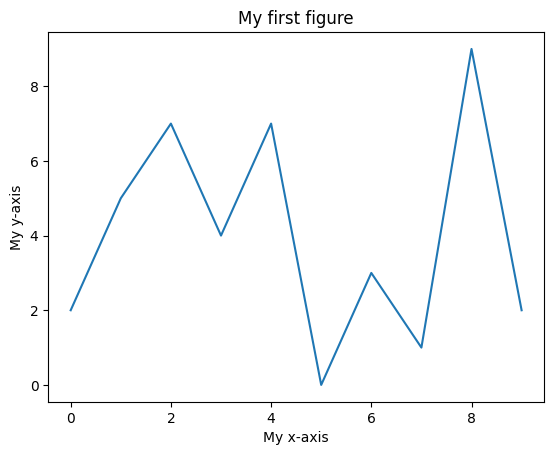

In [18]:
a=np.array([2, 5, 7, 4, 7, 0, 3, 1, 9, 2])

plt.plot(a)                   # plot the points in the array a.
plt.title("My first figure")  # Add a title to the figure
plt.xlabel("My x-axis")       # Give a label to the x-axis
plt.ylabel("My y-axis")       # Give a label to the y-axis
plt.show()                    # Tell matplotlib to output the figure.
                              # Not strictly required in notebooks (but a bit neater).

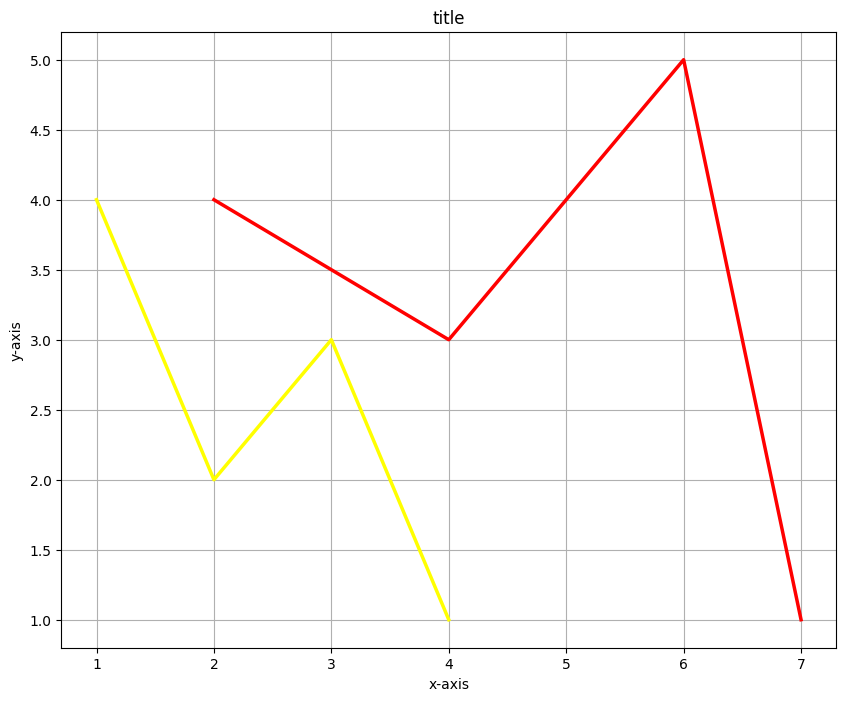

In [ ]:
x = np.arange(10)
fig , ax = plt.subplots(figsize=(10,8))
First = np.array([2,4,6 , 7, 4, 3,5 ,1])
Second = np.array([1,2,3,4 , 4, 2,3 , 1])

ax.plot(First[0:4],First[4:8],color='red',linewidth=2.5)
ax.plot(Second[0:4],Second[4:8], color='yellow',linewidth = 2.5)
plt.grid(visible=True)
ax.set_title('title')
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
plt.show()


In [ ]:
def subfigures(a):
    fig , axes = plt.subplots(1,2)
    ax1 = axes[0]
    ax2 = axes[1]
    x = a[:,0]
    y = a[:,1]
    ax1.plot(x,y)
    ax2.scatter(x= x , y= y , c=a[:,2],s=a[:,3])
    plt.show()
    return fig


(462, 770, 3)
The image consists of 355740 pixels


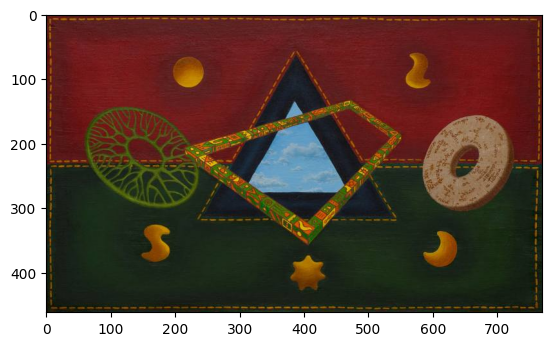

In [ ]:
painting=plt.imread("painting.jpg")
print(painting.shape) # first is height second is width and third is rgb
print(f"The image consists of {painting.shape[0] * painting.shape[1]} pixels")
plt.imshow(painting)
plt.show()

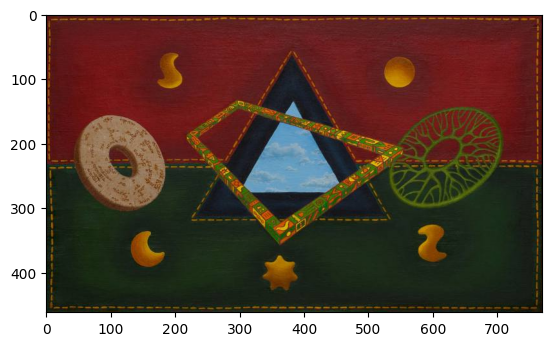

In [26]:
plt.imshow(painting[:,::-1])

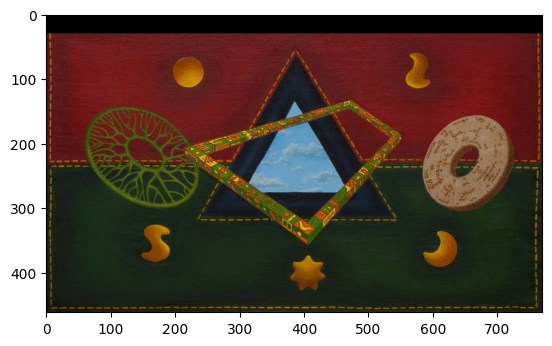

In [27]:
painting2 = painting.copy()    # don't mess the original painting!
painting2[0:30, :, :] = 1.0    # max value for all three components produces white
plt.imshow(painting2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..178.26788036410923].


(462, 770, 3)


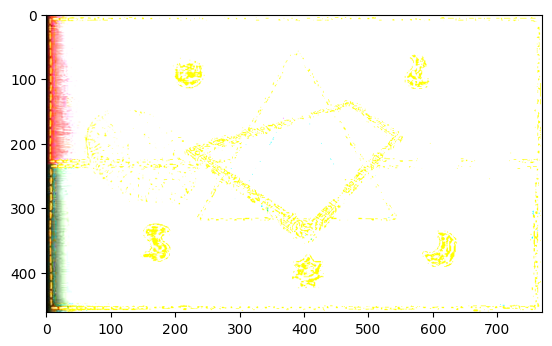

In [28]:
def fadex(image):
    height, width = image.shape[:2]
    m=np.linspace(0,1, width).reshape(1,width,1)
    result = image*m         
    return result

modified=fadex(painting)
print(modified.shape)
plt.imshow(modified)

In [24]:
# axis=0 means operate along the rows (i.e., vertically)
# axis=1 means operate along the cols (i.e., horizontally)

In [32]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt

def to_red(rgb_image):
    """
    Isolates the red channel of an RGB image by zeroing out green and blue.

    Args:
        rgb_image (np.array): A NumPy array representing a color image.

    Returns:
        np.array: A 3D array with only the red channel's data preserved.
    """
    # Create a copy to avoid modifying the original image array
    red_only = rgb_image.copy()
    # Zero out the green channel (index 1)
    red_only[:, :, 1] = 0
    # Zero out the blue channel (index 2)
    red_only[:, :, 2] = 0
    return red_only

def to_green(rgb_image):
    """
    Isolates the green channel of an RGB image by zeroing out red and blue.

    Args:
        rgb_image (np.array): A NumPy array representing a color image.

    Returns:
        np.array: A 3D array with only the green channel's data preserved.
    """
    green_only = rgb_image.copy()
    # Zero out the red channel (index 0)
    green_only[:, :, 0] = 0
    # Zero out the blue channel (index 2)
    green_only[:, :, 2] = 0
    return green_only

def to_blue(rgb_image):
    """
    Isolates the blue channel of an RGB image by zeroing out red and green.

    Args:
        rgb_image (np.array): A NumPy array representing a color image.

    Returns:
        np.array: A 3D array with only the blue channel's data preserved.
    """
    blue_only = rgb_image.copy()
    # Zero out the red channel (index 0)
    blue_only[:, :, 0] = 0
    # Zero out the green channel (index 1)
    blue_only[:, :, 1] = 0
    return blue_only

def to_grayscale(rgb_image):
    """
    Converts a 3D RGB image array to a 2D grayscale image array.

    Args:
        rgb_image (np.array): A NumPy array with shape (height, width, 3)
                              representing a color image.

    Returns:
        np.array: A NumPy array with shape (height, width) representing the
                  grayscale image.
    """
    # The weights for Red, Green, and Blue channels respectively
    weights = np.array([0.2126, 0.7152, 0.0722])

    # The dot product is a concise way to perform the weighted sum.
    # It multiplies the last axis of the image (the 3 color channels)
    # with the weights array and sums the result.
    # It's equivalent to np.sum(rgb_image * weights, axis=2)
    grayscale_image = np.dot(rgb_image[...,:3], weights)

    return grayscale_image

def main():
    painting = plt.imread('painting.png')
    
    
    grayscale = to_grayscale(painting)
    plt.imshow(grayscale,cmap='gist_gray')


    fig, ax = plt.subplots(3, 1, figsize=(8, 12))
    
    fig.suptitle('RGB Color Channels', fontsize=16)

    red_channel = to_red(painting)
    green_channel = to_green(painting)
    blue_channel = to_blue(painting)

    plt.title("Grayscale Painting")
    ax[0].imshow(red_channel)
    ax[0].set_title("Red Channel")
    ax[0].axis('off')
    
    # Display the green channel in the middle subplot
    ax[1].imshow(green_channel)
    ax[1].set_title("Green Channel")
    ax[1].axis('off')

    # Display the blue channel in the bottom subplot
    ax[2].imshow(blue_channel)
    ax[2].set_title("Blue Channel")
    ax[2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    
    plt.show()

